# CatBoost Model Evaluation

This notebook evaluates the selected **global CatBoost demand-forecasting model** after model comparison and hyperparameter tuning.

The goals are to:

1. inspect validation performance overall and by dish;
2. compare CatBoost against the seasonal `T7` baseline;
3. understand the largest forecasting errors and any systematic bias;
4. assess prediction calibration;
5. inspect feature importance using both CatBoost's built-in importance and validation permutation importance;
6. test how much the model depends on literal dish identity;
7. measure the incremental value of historical, calendar, and weather feature groups.

### Evaluation discipline

All diagnostic and ablation decisions in this notebook use the **validation split only**. The held-out test results are not used to choose features or modify the model.

The main metrics are:

- **MAE**: average absolute error in units sold;
- **RMSE**: penalizes larger misses more strongly;
- **WAPE**: absolute error relative to total observed demand, useful when dishes operate at different demand scales.


## 1. Setup and load experiment artifacts

The official experiment is generated by `ml/model_comparison.py`. Rather than rebuilding preprocessing manually in this notebook, the notebook reuses the same helper functions and saved artifacts so that evaluation is consistent with training.


In [2]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error


REPO_ROOT = Path("../..").resolve()
sys.path.insert(0, str(REPO_ROOT))

from ml.model_comparison import (
    load_dish_days,
    make_model,
    split_by_date,
)

ARTIFACT_DIR = Path("../artifacts/model_comparison")

metrics = pd.read_csv(ARTIFACT_DIR / "metrics.csv")
predictions = pd.read_csv(ARTIFACT_DIR / "predictions.csv")
predictions["DEMAND_DATE"] = pd.to_datetime(predictions["DEMAND_DATE"])

with open(ARTIFACT_DIR / "run.json", "r") as file:
    run_metadata = json.load(file)

# Rebuild exactly the same dish-day table and chronological split used by training.
_, long_df = load_dish_days()
splits = split_by_date(long_df)

train_df = splits["train"]
validation_df = splits["validation"]

numeric_features = [
    column
    for column in long_df.columns
    if column not in ("DEMAND_DATE", "DISH", "DEMAND")
]

catboost_params = run_metadata["selected_parameters"]["CatBoost"]

def regression_metrics(actual, predicted):
    """Return the three evaluation metrics used throughout this notebook."""
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)

    return {
        "MAE": float(mean_absolute_error(actual, predicted)),
        "RMSE": float(np.sqrt(mean_squared_error(actual, predicted))),
        "WAPE_pct": float(
            np.abs(actual - predicted).sum()
            / np.abs(actual).sum()
            * 100
        ),
    }

catboost_params


{'depth': 6, 'iterations': 200, 'l2_leaf_reg': 3, 'learning_rate': 0.05}

## 2. Model Selection

Ridge Regression, Random Forest, XGBoost, and CatBoost were compared using the same chronological train/validation/test split.

CatBoost was selected as the final forecasting model because it achieved the lowest validation error among the candidate models:

| Model | Validation MAE | RMSE | WAPE |
|---|---:|---:|---:|
| Ridge | 4.954 | 7.092 | 27.37% |
| Random Forest | 4.785 | 7.080 | 26.44% |
| XGBoost | 4.825 | 7.026 | 26.65% |
| **CatBoost** | **4.710** | **6.898** | **26.02%** |

CatBoost was therefore selected based on validation performance, with MAE used as the primary model-selection metric.

## 3. Validation performance

### 3.1 Overall and per-dish CatBoost performance

The global CatBoost model is trained across all dishes, but its predictions are evaluated separately for each dish to ensure that the overall score is not hiding poor performance on individual menu items.


In [3]:
catboost_validation = metrics[
    (metrics["split"] == "validation")
    & (metrics["model"] == "CatBoost")
][
    [
        "dish",
        "MAE",
        "RMSE",
        "WAPE_pct",
        "negative_predictions",
    ]
]

catboost_validation


,dish,MAE,RMSE,WAPE_pct,negative_predictions
40,ALL,4.709594,6.897685,26.019499,0
41,CALAMARI,1.906554,2.337225,48.952061,0
42,FISH,1.898175,2.536397,43.982111,0
43,PRAWNS,3.488854,4.322653,29.926961,0
44,CHICKEN,6.872519,10.428303,21.756933,0
45,KOFTA,5.608118,6.823991,30.885286,0
46,LAMB,7.738207,9.846362,21.573872,0
47,STEAK,5.454735,7.085054,25.706480,0


### Result

Overall validation performance is approximately **MAE 4.710**, **RMSE 6.898**, and **WAPE 26.02%**, with **no negative predictions**.

Absolute error is naturally lower for low-volume dishes such as Calamari and Fish, while their WAPE is higher because a small unit error represents a larger fraction of their typical demand. Higher-volume dishes such as Chicken and Lamb have larger MAE in raw units but substantially lower relative error.


### 3.2 CatBoost versus the seasonal `T7` baseline

A useful forecasting model should improve on a simple rule such as using demand from seven recorded observations earlier. This comparison checks whether CatBoost's overall improvement is also present for every individual dish.


In [4]:
seasonal = metrics[
    (metrics["split"] == "validation")
    & (metrics["model"] == "Seasonal T7")
    & (metrics["dish"] != "ALL")
][["dish", "MAE", "RMSE", "WAPE_pct"]].rename(
    columns={
        "MAE": "Seasonal_MAE",
        "RMSE": "Seasonal_RMSE",
        "WAPE_pct": "Seasonal_WAPE_pct",
    }
)

catboost = metrics[
    (metrics["split"] == "validation")
    & (metrics["model"] == "CatBoost")
    & (metrics["dish"] != "ALL")
][["dish", "MAE", "RMSE", "WAPE_pct"]].rename(
    columns={
        "MAE": "CatBoost_MAE",
        "RMSE": "CatBoost_RMSE",
        "WAPE_pct": "CatBoost_WAPE_pct",
    }
)

per_dish_comparison = seasonal.merge(catboost, on="dish")

per_dish_comparison["MAE_improvement_pct"] = (
    (
        per_dish_comparison["Seasonal_MAE"]
        - per_dish_comparison["CatBoost_MAE"]
    )
    / per_dish_comparison["Seasonal_MAE"]
    * 100
)

per_dish_comparison[
    [
        "dish",
        "Seasonal_MAE",
        "CatBoost_MAE",
        "MAE_improvement_pct",
        "Seasonal_RMSE",
        "CatBoost_RMSE",
        "Seasonal_WAPE_pct",
        "CatBoost_WAPE_pct",
    ]
]


,dish,Seasonal_MAE,CatBoost_MAE,MAE_improvement_pct,Seasonal_RMSE,CatBoost_RMSE,Seasonal_WAPE_pct,CatBoost_WAPE_pct
0,CALAMARI,2.245614,1.906554,15.098770,3.000000,2.337225,57.657658,48.952061
1,FISH,2.438596,1.898175,22.161157,3.446330,2.536397,56.504065,43.982111
2,PRAWNS,4.991228,3.488854,30.100297,5.899004,4.322653,42.814146,29.926961
3,CHICKEN,10.517544,6.872519,34.656618,15.572412,10.428303,33.296307,21.756933
4,KOFTA,6.991228,5.608118,19.783511,9.118614,6.823991,38.502415,30.885286
5,LAMB,10.210526,7.738207,24.213434,12.372862,9.846362,28.466618,21.573872
6,STEAK,7.368421,5.454735,25.971459,10.173064,7.085054,34.725093,25.706480


### Result

CatBoost outperforms the seasonal `T7` baseline on **all seven dishes** across MAE, RMSE, and WAPE.

The per-dish MAE reduction ranges from approximately **15.1% for Calamari** to **34.7% for Chicken**. This is important because it shows that the global improvement is not being produced only by one or two high-volume dishes.


## 4. Error analysis

Check when model fails.

- positive error → the model underpredicted
- negative error → the model overpredicted


In [5]:
cat_val = predictions[
    predictions["split"] == "validation"
].copy()

cat_val["ERROR"] = cat_val["DEMAND"] - cat_val["CatBoost"]
cat_val["ABS_ERROR"] = cat_val["ERROR"].abs()

context_features = [
    "DEMAND_T1",
    "DEMAND_T7",
    "MEAN_SAME_WDAY_W4",
    "WEEKEND",
    "ISHOLIDAY",
    "PRECIPITATION",
    "AIR_TEMPERATURE",
]

cat_val_context = cat_val.merge(
    long_df[
        [
            "DEMAND_DATE",
            "DISH",
            *context_features,
        ]
    ],
    on=["DEMAND_DATE", "DISH"],
    how="left",
    validate="one_to_one",
)

worst_context = (
    cat_val_context
    .sort_values("ABS_ERROR", ascending=False)
    .head(20)
)

worst_context[
    [
        "DEMAND_DATE",
        "DISH",
        "DEMAND",
        "CatBoost",
        "ERROR",
        "ABS_ERROR",
        *context_features,
    ]
]


,DEMAND_DATE,DISH,DEMAND,CatBoost,ERROR,ABS_ERROR,DEMAND_T1,DEMAND_T7,MEAN_SAME_WDAY_W4,WEEKEND,ISHOLIDAY,PRECIPITATION,AIR_TEMPERATURE
426,2015-06-17,CHICKEN,93,26.790902,66.209098,66.209098,31,21,25.75,0,0,0.0,18.750000
642,2015-06-05,LAMB,70,37.310183,32.689817,32.689817,40,56,50.75,0,0,0.0,29.958333
405,2015-05-27,CHICKEN,3,30.215393,-27.215393,27.215393,33,31,30.00,0,0,0.0,12.858333
348,2015-03-31,CHICKEN,55,28.744684,26.255316,26.255316,31,26,27.50,0,0,2.2,9.591667
638,2015-06-01,LAMB,53,28.420262,24.579738,24.579738,17,30,25.75,0,0,0.0,16.733333
742,2015-05-22,STEAK,1,24.999644,-23.999644,23.999644,18,27,27.50,0,0,0.0,16.725000
412,2015-06-03,CHICKEN,48,24.083645,23.916355,23.916355,37,3,20.75,0,0,0.0,23.641667
656,2015-06-19,LAMB,62,38.762549,23.237451,23.237451,43,37,51.25,0,0,0.0,14.300000
621,2015-05-15,LAMB,61,37.780784,23.219216,23.219216,27,44,46.75,0,0,0.5,13.508333
747,2015-05-27,STEAK,43,21.078772,21.921228,21.921228,25,14,18.50,0,0,0.0,12.858333


### Result: largest misses

The largest errors are dominated by unexpected demand shocks.

Examples from validation include:

- Chicken on 2015-06-17: actual demand 93 while recent historical signals were around 21–31 units, so the prediction near 27 was consistent with the available history.
- Chicken on 2015-05-27: actual demand fell to 3 even though `T1`, `T7`, and same-weekday history were all around 30.
- Steak on 2015-05-22: actual demand fell to 1 despite recent historical values around the mid-20s.

These cases suggest that many of the largest misses are caused by sudden spikes or drops that are not supported by the available historical features. Can possibly be improved by richer external context in our own model, things such as promotions, events, closures, ect.


### 4.1 Bias by dish

Mean signed residual checks whether CatBoost systematically predicts too high or too low for particular dishes.


In [6]:
dish_error = (
    cat_val
    .groupby("DISH")
    .agg(
        mean_error=("ERROR", "mean"),
        mean_absolute_error=("ABS_ERROR", "mean"),
        actual_mean=("DEMAND", "mean"),
        predicted_mean=("CatBoost", "mean"),
    )
    .reset_index()
)

dish_error


,DISH,mean_error,mean_absolute_error,actual_mean,predicted_mean
0,CALAMARI,-0.714951,1.906554,3.894737,4.609688
1,CHICKEN,1.297678,6.872519,31.587719,30.290041
2,FISH,-0.458374,1.898175,4.315789,4.774164
3,KOFTA,-1.235741,5.608118,18.157895,19.393635
4,LAMB,3.198105,7.738207,35.868421,32.670316
5,PRAWNS,0.701476,3.488854,11.657895,10.956419
6,STEAK,-0.628613,5.454735,21.219298,21.847911


### Result

Most dish-level biases are relatively small, but **Lamb stands out with a mean error of about +3.20 units**, meaning it is systematically underpredicted over the validation period.

This is worth monitoring, but it is not a reason to hard-code a Lamb-specific correction. In the eventual SME system, this type of pattern should be handled generically through learned per-`dish_id` calibration based on local residual history.


### 4.2 Calibration by predicted demand level

Grouping observations by actual demand can mechanically create an apparent regression-to-the-mean pattern. A cleaner calibration check groups observations by model predictions, then compares average predicted and observed demand within each prediction band.


In [7]:
cat_val["PREDICTED_LEVEL"] = pd.qcut(
    cat_val["CatBoost"],
    q=4,
    labels=[
        "Low",
        "Medium-Low",
        "Medium-High",
        "High",
    ],
    duplicates="drop",
)

prediction_calibration = (
    cat_val
    .groupby("PREDICTED_LEVEL", observed=True)
    .agg(
        mean_actual=("DEMAND", "mean"),
        mean_prediction=("CatBoost", "mean"),
        mean_error=("ERROR", "mean"),
        mean_absolute_error=("ABS_ERROR", "mean"),
    )
    .reset_index()
)

prediction_calibration


,PREDICTED_LEVEL,mean_actual,mean_prediction,mean_error,mean_absolute_error
0,Low,3.770000,4.271670,-0.501670,1.713724
1,Medium-Low,11.638191,11.511074,0.127117,3.853132
2,Medium-High,21.497487,21.167941,0.329546,5.280251
3,High,35.480000,34.201749,1.278251,7.989841


### Result

CatBoost is **reasonably calibrated across predicted demand levels**:

- low predicted demand is slightly overpredicted;
- medium-low and medium-high bands are close to unbiased;
- the highest predicted-demand band is underpredicted by only about **1.28 units on average**.

This suggests that the extreme errors observed earlier are primarily unusual demand shocks rather than a broad tendency for CatBoost to suppress all high-demand predictions.


## 5. Reconstruct the selected CatBoost model

The saved experiment metadata contains the hyperparameters selected by training-only time-series cross-validation. The model is reconstructed on the **original training split only** for feature analysis and ablation experiments.


In [8]:
X_train = train_df[["DISH", *numeric_features]].copy()
y_train = train_df["DEMAND"].copy()

X_val = validation_df[["DISH", *numeric_features]].copy()
y_val = validation_df["DEMAND"].copy()

catboost_model = make_model(
    "CatBoost",
    numeric_features,
    catboost_params,
)

catboost_model.fit(X_train, y_train)

baseline_predictions = catboost_model.predict(X_val)
baseline_metrics = regression_metrics(y_val, baseline_predictions)

pd.DataFrame(
    [{"model": "Selected CatBoost", **baseline_metrics}]
)


,model,MAE,RMSE,WAPE_pct
0,Selected CatBoost,4.709594,6.897685,26.019499


The reconstructed model reproduces the official validation result (approximately **MAE 4.710**), confirming that the notebook is analysing the same selected model configuration.


## 6. Feature importance

Two complementary importance methods are used:

1. **CatBoost built-in feature importance** describes how strongly the fitted model used each feature internally.
2. **Validation permutation importance** measures how much validation MAE worsens when a feature's information is destroyed.

Neither measure implies causality, and correlated features can share or substitute for one another.


### 6.1 CatBoost built-in feature importance


In [9]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": catboost_model.get_feature_importance(),
})

feature_importance = (
    feature_importance
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance.head(20)


,feature,importance
0,SATURDAY,14.441330
1,MEAN_SAME_WDAY_W3,13.685679
2,CUM_DEMAND_T6,9.504870
3,MEAN_SAME_WDAY_W4,8.500036
4,CUM_DEMAND_T7,6.429043
5,DEMAND_T6,4.533052
6,CUM_DEMAND_T5,4.298328
7,AIR_TEMPERATURE,3.722092
8,MEAN_SAME_WDAY_W2,3.635015
9,CUM_DEMAND_T4,2.441203


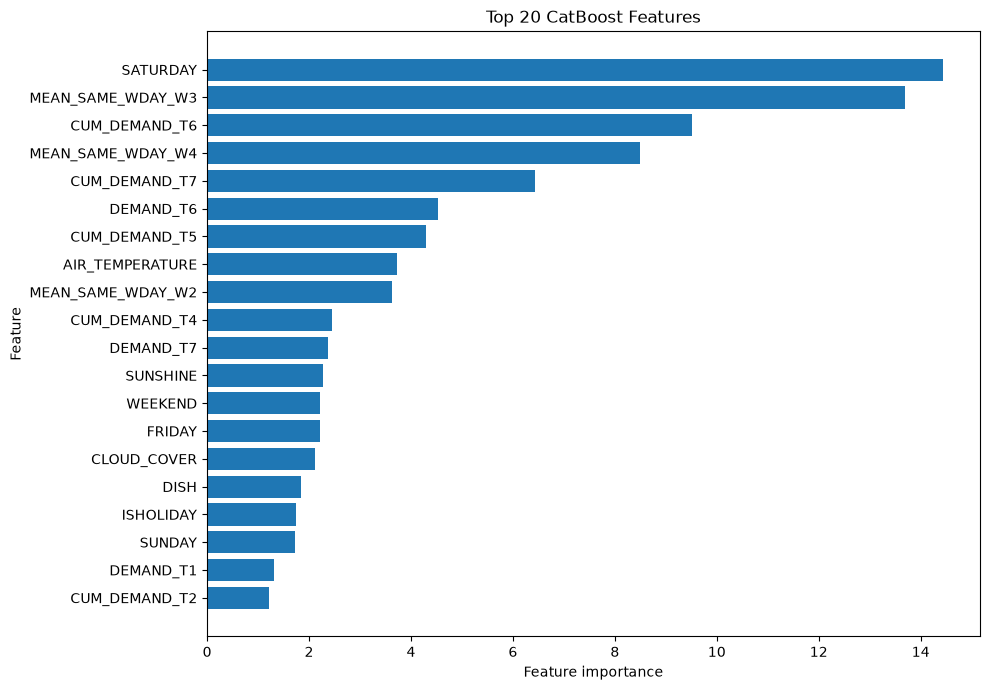

In [10]:
top_features = (
    feature_importance
    .head(20)
    .sort_values("importance")
)

plt.figure(figsize=(10, 7))
plt.barh(
    top_features["feature"],
    top_features["importance"],
)

plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Top 20 CatBoost Features")
plt.tight_layout()
plt.show()


### Result

The built-in importance is dominated by **weekly/temporal patterns and historical demand**. `SATURDAY`, same-weekday demand means, and cumulative recent-demand features are among the strongest inputs.

`DISH` is useful but is not dominant, appearing well below the leading historical and temporal features. Weather variables such as air temperature, sunshine, and cloud cover contribute, but at lower importance.

This is encouraging for transferability because much of the model's predictive structure comes from generic demand behaviour rather than memorising the seven source dishes. 
However, calendar and weather relationships were learned from the German source domain and should not be assumed to transfer unchanged to Singapore.


### 6.2 Validation permutation importance

For each feature, its validation values are shuffled while all other features remain unchanged. The increase in MAE measures how much predictive performance is lost when that feature's information is destroyed.

Each feature is shuffled 10 times to reduce sensitivity to a single random permutation.


In [11]:
rng = np.random.default_rng(42)
n_repeats = 10
permutation_results = []

for feature in X_val.columns:
    mae_increases = []

    for _ in range(n_repeats):
        X_permuted = X_val.copy()
        X_permuted[feature] = rng.permutation(
            X_permuted[feature].to_numpy()
        )

        permuted_predictions = catboost_model.predict(
            X_permuted
        )

        permuted_mae = mean_absolute_error(
            y_val,
            permuted_predictions,
        )

        mae_increases.append(
            permuted_mae - baseline_metrics["MAE"]
        )

    permutation_results.append({
        "feature": feature,
        "mae_increase_mean": np.mean(mae_increases),
        "mae_increase_std": np.std(mae_increases),
    })

permutation_importance_df = (
    pd.DataFrame(permutation_results)
    .sort_values("mae_increase_mean", ascending=False)
    .reset_index(drop=True)
)

permutation_importance_df.head(20)


,feature,mae_increase_mean,mae_increase_std
0,MEAN_SAME_WDAY_W3,1.267230,0.088365
1,CUM_DEMAND_T7,0.694942,0.068586
2,MEAN_SAME_WDAY_W4,0.606017,0.041015
3,CUM_DEMAND_T6,0.525720,0.051005
4,DEMAND_T6,0.393040,0.040746
5,SATURDAY,0.265110,0.028667
6,CUM_DEMAND_T4,0.263351,0.028485
7,DISH,0.255502,0.019313
8,MEAN_SAME_WDAY_W2,0.183330,0.027112
9,CUM_DEMAND_T5,0.163895,0.016705


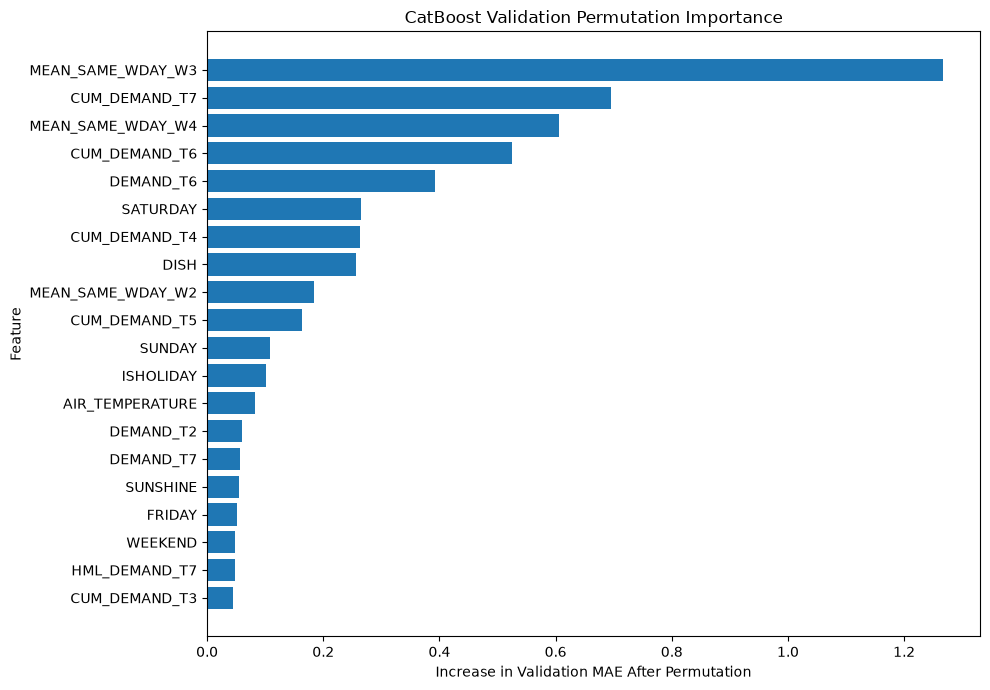

In [12]:
top_permutation = (
    permutation_importance_df
    .head(20)
    .sort_values("mae_increase_mean")
)

plt.figure(figsize=(10, 7))
plt.barh(
    top_permutation["feature"],
    top_permutation["mae_increase_mean"],
)

plt.xlabel("Increase in Validation MAE After Permutation")
plt.ylabel("Feature")
plt.title("CatBoost Validation Permutation Importance")
plt.tight_layout()
plt.show()


### Result

Validation permutation importance provides stronger evidence that the model relies primarily on **historical demand behaviour**:

- `MEAN_SAME_WDAY_W3` is the strongest feature; scrambling it increases validation MAE by about **1.27**.
- Cumulative demand at `T7` and `T6`, same-weekday history, and `DEMAND_T6` are also highly influential.
- `DISH` is useful but secondary, increasing MAE by about **0.26** when shuffled.
- Calendar signals such as Saturday, Sunday, and holidays add measurable information.
- Weather contributes, but its individual importance is smaller than the strongest demand-history features.

Because several historical features are correlated, individual permutation scores can understate the importance of the feature family as a whole. This motivates the group ablation later in the notebook.


## 7. Dish-identity ablation

This experiment tests whether the global model depends heavily on knowing the literal dish identity.

The selected CatBoost hyperparameters are kept fixed. The only change is removing `DISH` from both training and validation inputs. This isolates the value of dish identity from the value of historical and contextual features.


In [13]:
X_train_no_dish = train_df[numeric_features].copy()
X_val_no_dish = validation_df[numeric_features].copy()

catboost_no_dish = CatBoostRegressor(
    random_seed=42,
    loss_function="RMSE",
    verbose=False,
    **catboost_params,
)

catboost_no_dish.fit(
    X_train_no_dish,
    y_train,
)

no_dish_predictions = catboost_no_dish.predict(
    X_val_no_dish
)

dish_ablation = pd.DataFrame([
    {
        "model": "CatBoost + DISH",
        **baseline_metrics,
    },
    {
        "model": "CatBoost without DISH",
        **regression_metrics(
            y_val,
            no_dish_predictions,
        ),
    },
])

dish_ablation


,model,MAE,RMSE,WAPE_pct
0,CatBoost + DISH,4.709594,6.897685,26.019499
1,CatBoost without DISH,4.750588,6.988700,26.245980


### Result

Removing `DISH` increases validation MAE from approximately **4.710 to 4.751**, a deterioration of only about **0.87%**.

Therefore, dish identity provides real predictive information, but most model performance is retained through **dish-independent historical demand and contextual features**. The final model should still keep `DISH`, since it improves accuracy without dominating the forecast.


## 8. Feature-group ablation

This experiment measures the contribution of three feature families:

- **History**: lags, cumulative demand, same-weekday means, recent range, and above/below-mean counts;
- **Calendar**: weekday, month, holiday, and weekend indicators;
- **Weather**: wind, cloud cover, precipitation, sunshine, and air temperature.

`DISH` is kept in every variant so that the experiment isolates the value of the feature groups rather than changing dish identity at the same time.

The same selected CatBoost hyperparameters are used for every variant; the models are **not retuned** for each feature subset.


In [14]:
history_features = (
    [f"DEMAND_T{i}" for i in range(1, 8)]
    + [f"MEAN_SAME_WDAY_W{i}" for i in range(2, 5)]
    + [f"CUM_DEMAND_T{i}" for i in range(2, 8)]
    + [
        "HML_DEMAND_T7",
        "NO_DAYS_ABOVE_7D_MEAN",
        "NO_DAYS_BELOW_7D_MEAN",
    ]
)

calendar_features = [
    "MONDAY",
    "TUESDAY",
    "WEDNESDAY",
    "THURSDAY",
    "FRIDAY",
    "SATURDAY",
    "SUNDAY",
    "MONTH_JAN",
    "MONTH_FEB",
    "MONTH_MAR",
    "MONTH_APR",
    "MONTH_MAY",
    "MONTH_JUN",
    "MONTH_JUL",
    "MONTH_AUG",
    "MONTH_SEP",
    "MONTH_OCT",
    "MONTH_NOV",
    "MONTH_DEC",
    "ISHOLIDAY",
    "WEEKEND",
]

weather_features = [
    "WIND",
    "CLOUD_COVER",
    "PRECIPITATION",
    "SUNSHINE",
    "AIR_TEMPERATURE",
]

grouped_features = (
    history_features
    + calendar_features
    + weather_features
)

# Guard against accidentally omitting or duplicating a production feature.
assert set(grouped_features) == set(numeric_features)
assert len(grouped_features) == len(set(grouped_features))

def evaluate_feature_set(name, features):
    columns = ["DISH", *features]

    X_train_subset = train_df[columns]
    X_val_subset = validation_df[columns]

    model = CatBoostRegressor(
        random_seed=42,
        cat_features=["DISH"],
        loss_function="RMSE",
        verbose=False,
        **catboost_params,
    )

    model.fit(
        X_train_subset,
        y_train,
    )

    subset_predictions = model.predict(
        X_val_subset
    )

    return {
        "feature_set": name,
        "num_numeric_features": len(features),
        **regression_metrics(
            y_val,
            subset_predictions,
        ),
    }


In [15]:
feature_group_ablation = pd.DataFrame([
    evaluate_feature_set(
        "History + DISH",
        history_features,
    ),
    evaluate_feature_set(
        "History + Calendar + DISH",
        history_features + calendar_features,
    ),
    evaluate_feature_set(
        "History + Weather + DISH",
        history_features + weather_features,
    ),
    evaluate_feature_set(
        "History + Calendar + Weather + DISH",
        history_features + calendar_features + weather_features,
    ),
])

feature_group_ablation


,feature_set,num_numeric_features,MAE,RMSE,WAPE_pct
0,History + DISH,19,5.085639,7.414705,28.097064
1,History + Calendar + DISH,40,4.840246,7.092324,26.741322
2,History + Weather + DISH,24,4.898602,7.163414,27.063724
3,History + Calendar + Weather + DISH,45,4.709594,6.897685,26.019499


### Result

Key observations:

- adding **calendar** to history reduces MAE by about **4.8%**
- adding **weather** to history reduces MAE by about **3.7%**
- adding weather when calendar is already present gives a further **2.7%** improvement
- adding calendar when weather is already present gives a further **3.9%** improvement
- the full contextual model improves MAE by about **7.4%** over history + dish identity alone

Both calendar and weather therefore provide incremental predictive value. The final feature set should retain all three groups.



## 9. Evaluation conclusions

1. **CatBoost is a strong global forecaster.**  
   Validation performance is approximately MAE **4.710**, RMSE **6.898**, and WAPE **26.02%**, with no negative demand predictions.

2. **The improvement is consistent across dishes.**  
   CatBoost beats the seasonal `T7` baseline on all seven dishes. Per-dish MAE reductions are approximately **15%–35%**.

3. **The largest errors are usually unexpected demand shocks.**  
   Extreme spikes and drops often occur despite ordinary recent demand indicators, suggesting that richer event, promotion, closure, or operational context may be needed to anticipate them.

4. **The model is reasonably calibrated.**  
   Average observed and predicted demand remain close across prediction quartiles. Lamb shows a moderate dish-specific underprediction bias, but there is no broad high-demand underprediction failure.

5. **Historical behaviour carries most of the predictive signal.**  
   Same-weekday history and cumulative recent demand dominate validation permutation importance.

6. **Dish identity helps but is not essential.**  
   Removing `DISH` worsens validation MAE by only about **0.87%**, indicating that most predictive performance comes from generic behavioural and contextual features.

7. **Calendar and weather context both add value.**  
   The full history + calendar + weather model improves validation MAE by about **7.4%** relative to history + dish identity alone.

### Implication for deployment

The final base-model design should retain:

- dish identity;
- historical demand features;
- calendar features;
- weather features.

For local deployment, the **feature structure** can be reused, while calendar/weather relationships and dish-specific residual behaviour should be adapted using Singapore context and future SME-local sales evidence rather than hard-coded assumptions.
